In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, 
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, 
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error
)
import xgboost as xgb
import lightgbm as lgb
import warnings
import pickle
import time
import shap
import pymysql
from datetime import datetime

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
DB_CONFIG = {
    'host': 'localhost',
    'port': 3306,
    'user': 'root',
    'password': 'Qq735228(',
    'database': 'chengdu_house',
    'charset': 'utf8mb4'
}

conn = pymysql.connect(**DB_CONFIG)

df_listings = pd.read_sql("SELECT * FROM house_listings", conn)

df_poi = pd.read_sql("SELECT * FROM house_poi", conn)

conn.close()

print(f"房源数据: {len(df_listings):,} 条")
print(f"POI数据: {len(df_poi):,} 条")
print(f"\n房源字段: {list(df_listings.columns)}")
print(f"\nPOI字段: {list(df_poi.columns)}")

房源数据: 10,758 条
POI数据: 2,041 条

房源字段: ['id', 'title', 'total_price', 'unit_price', 'area_size', 'layout_full', 'orientation', 'floor', 'build_year', 'community', 'district', 'sub_district', 'street', 'tags', 'area_code', 'detail_url', 'source', 'created_at']

POI字段: ['id', 'community', 'street', 'lng', 'lat', 'nearest_subway_dist', 'subway_count', 'school_count', 'poi_updated_at']


清洗后: 10,753 条


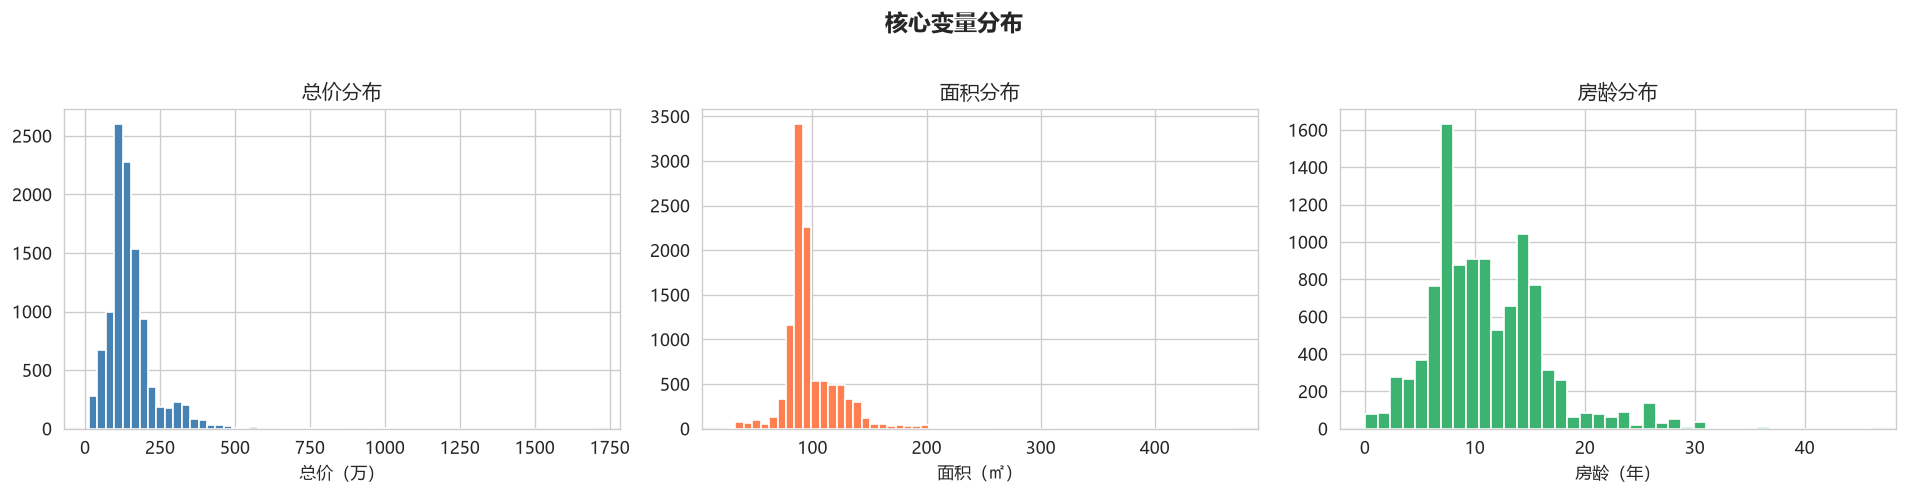

In [3]:
# 合并POI
df = df_listings.merge(
    df_poi[['community', 'street', 'lng', 'lat',
            'nearest_subway_dist', 'subway_count', 'school_count']],
    on=['community', 'street'], how='left'
)

# 目标变量
df['price_num'] = df['total_price'].str.extract(r'(\d+\.?\d*)').astype(float)

# 数值特征
df['area_num'] = df['area_size'].str.extract(r'(\d+\.?\d*)').astype(float)
df['room_count'] = df['layout_full'].str.extract(r'(\d+)\s*室').astype(float)
df['hall_count'] = df['layout_full'].str.extract(r'(\d+)\s*厅').astype(float)
df['toilet_count'] = df['layout_full'].str.extract(r'(\d+)\s*卫').astype(float)
df['build_year_num'] = df['build_year'].str.extract(r'(\d{4})').astype(float)
df['house_age'] = 2026 - df['build_year_num']

# 标签特征
df['has_subway'] = df['tags'].str.contains('地铁', na=False).astype(int)

# 清洗
df = df.dropna(subset=['price_num', 'area_num'])
df = df[(df['price_num'] >= 10) & (df['price_num'] <= 2000)]
df = df[(df['area_num'] >= 20) & (df['area_num'] <= 500)]

# POI缺失填充
df['nearest_subway_dist'] = df['nearest_subway_dist'].fillna(-1)
df['subway_count'] = df['subway_count'].fillna(0).astype(int)
df['school_count'] = df['school_count'].fillna(0).astype(int)
df['lng'] = df['lng'].fillna(0)
df['lat'] = df['lat'].fillna(0)

# 基础特征列
base_features = [
    'area_num', 'room_count', 'hall_count', 'toilet_count',
    'house_age', 'nearest_subway_dist', 'subway_count', 'school_count',
    'has_subway', 'lng', 'lat', 'district', 'community', 'street'
]

print(f"清洗后: {len(df):,} 条")

# 分布图
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['price_num'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('总价分布')
axes[0].set_xlabel('总价（万）')
axes[1].hist(df['area_num'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('面积分布')
axes[1].set_xlabel('面积（㎡）')
axes[2].hist(df['house_age'].dropna(), bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('房龄分布')
axes[2].set_xlabel('房龄（年）')
plt.suptitle('核心变量分布', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
X_base = df[base_features].copy()
y = df['price_num'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

In [5]:
def create_features(X_raw, y=None, is_train=True, enc_map=None):
    F = X_raw.copy()
    
    # 交互特征
    F['area_x_subway'] = F['area_num'] * F['subway_count']
    F['area_x_school'] = F['area_num'] * F['school_count']
    F['age_x_area'] = F['house_age'] * F['area_num']
    F['age_x_subwaydist'] = F['house_age'] * (F['nearest_subway_dist'].fillna(5000) + 1)
    F['subway_x_school'] = F['subway_count'] * F['school_count']
    F['room_density'] = F['room_count'] / (F['area_num'] + 1)
    F['area_per_room'] = F['area_num'] / (F['room_count'] + 1)
    
    # 非线性变换
    F['log_area'] = np.log1p(F['area_num'])
    F['area_squared'] = F['area_num'] ** 2
    F['sqrt_area'] = np.sqrt(F['area_num'])
    F['inv_subway_dist'] = 1 / (F['nearest_subway_dist'].fillna(5000) + 100)
    F['age_squared'] = F['house_age'] ** 2
    F['log_age'] = np.log1p(F['house_age'].clip(lower=0))
    
    # 分箱
    F['area_bin'] = pd.cut(F['area_num'], bins=[0,60,90,120,150,200,500],
                           labels=['<60','60-90','90-120','120-150','150-200','200+']).astype(str)
    F['age_bin'] = pd.cut(F['house_age'], bins=[-1,5,10,15,20,30,100],
                          labels=['新房','5-10年','10-15年','15-20年','20-30年','30年+']).astype(str)
    F['subway_bin'] = pd.cut(F['nearest_subway_dist'].fillna(9999),
                             bins=[-1,500,1000,2000,5000,99999],
                             labels=['<500m','500-1k','1k-2k','2k-5k','无地铁']).astype(str)
    
    # 目标编码
    global_mean = y.mean() if y is not None else 200.0
    
    if is_train and y is not None:
        enc_map = {'global_mean': global_mean}
        train_df = F.copy()
        train_df['_y'] = y
        smoothing = 10
        
        for col_name, group_col in [
            ('district_te', 'district'),
            ('area_bin_te', 'area_bin'),
            ('age_bin_te', 'age_bin'),
            ('subway_bin_te', 'subway_bin')
        ]:
            stats = train_df.groupby(group_col)['_y'].agg(['mean', 'count'])
            stats['smoothed'] = (stats['count']*stats['mean'] + smoothing*global_mean) / (stats['count']+smoothing)
            enc_map[col_name] = stats['smoothed'].to_dict()
        
        enc_map['district_mean'] = train_df.groupby('district')['_y'].mean().to_dict()
        enc_map['district_std'] = train_df.groupby('district')['_y'].std().to_dict()
        enc_map['district_median'] = train_df.groupby('district')['_y'].median().to_dict()
    
    gm = enc_map.get('global_mean', 200.0) if enc_map else 200.0
    
    F['district_te'] = F['district'].map(enc_map.get('district_te', {})).fillna(gm)
    F['area_bin_te'] = F['area_bin'].map(enc_map.get('area_bin_te', {})).fillna(gm)
    F['age_bin_te'] = F['age_bin'].map(enc_map.get('age_bin_te', {})).fillna(gm)
    F['subway_bin_te'] = F['subway_bin'].map(enc_map.get('subway_bin_te', {})).fillna(gm)
    F['district_price_mean'] = F['district'].map(enc_map.get('district_mean', {})).fillna(gm)
    F['district_price_std'] = F['district'].map(enc_map.get('district_std', {})).fillna(gm)
    F['district_price_median'] = F['district'].map(enc_map.get('district_median', {})).fillna(gm)
    
    # 组合特征
    F['total_rooms'] = F['room_count'] + F['hall_count']
    F['toilet_ratio'] = F['toilet_count'] / (F['room_count'] + 1)
    F['is_luxury'] = ((F['area_num'] > 150) & (F['subway_count'] >= 2)).astype(int)
    F['old_and_far'] = ((F['house_age'] > 20) & (F['nearest_subway_dist'].fillna(9999) > 2000)).astype(int)
    
    # 删除类别列
    F = F.drop(columns=['district','community','street','area_bin','age_bin','subway_bin'], errors='ignore')
    
    # 删除全NaN列
    all_nan = F.columns[F.isnull().all()].tolist()
    if all_nan:
        print(f"  删除全NaN列: {all_nan}")
        F = F.drop(columns=all_nan)
    
    # 填充剩余NaN
    for col in F.columns:
        if F[col].isnull().sum() > 0:
            med = F[col].median()
            F[col] = F[col].fillna(med if not pd.isna(med) else gm)
    
    return F, enc_map

t0 = time.time()

X_train_adv, enc_map = create_features(X_train, y_train, is_train=True)
X_test_adv, _ = create_features(X_test, y_test, is_train=False, enc_map=enc_map)

print(f"基础特征: {X_train.shape[1]} 个")
print(f"高级特征: {X_train_adv.shape[1]} 个")
print(f"耗时: {time.time()-t0:.2f}秒")

基础特征: 14 个
高级特征: 35 个
耗时: 0.09秒


In [6]:
fill_vals = X_train_adv.median().fillna(0)
X_train_filled = X_train_adv.fillna(fill_vals)
X_test_filled = X_test_adv.fillna(fill_vals)

# 删除残留NaN列
bad_cols = X_train_filled.columns[X_train_filled.isnull().any()].tolist()
if bad_cols:
    print(f"删除残留NaN列: {bad_cols}")
    X_train_filled = X_train_filled.drop(columns=bad_cols)
    X_test_filled = X_test_filled.drop(columns=bad_cols)

X_train_filled = X_train_filled.astype(float)
X_test_filled = X_test_filled.astype(float)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

print(f"\n标准化完成: 均值={np.mean(X_train_scaled):.6f} | 标准差={np.std(X_train_scaled, axis=0).mean():.4f}")

X_train_tree = X_train_filled.values
X_test_tree = X_test_filled.values
feature_names = list(X_train_filled.columns)

print(f"最终特征: {len(feature_names)} 个")


标准化完成: 均值=0.000000 | 标准差=1.0000
最终特征: 35 个


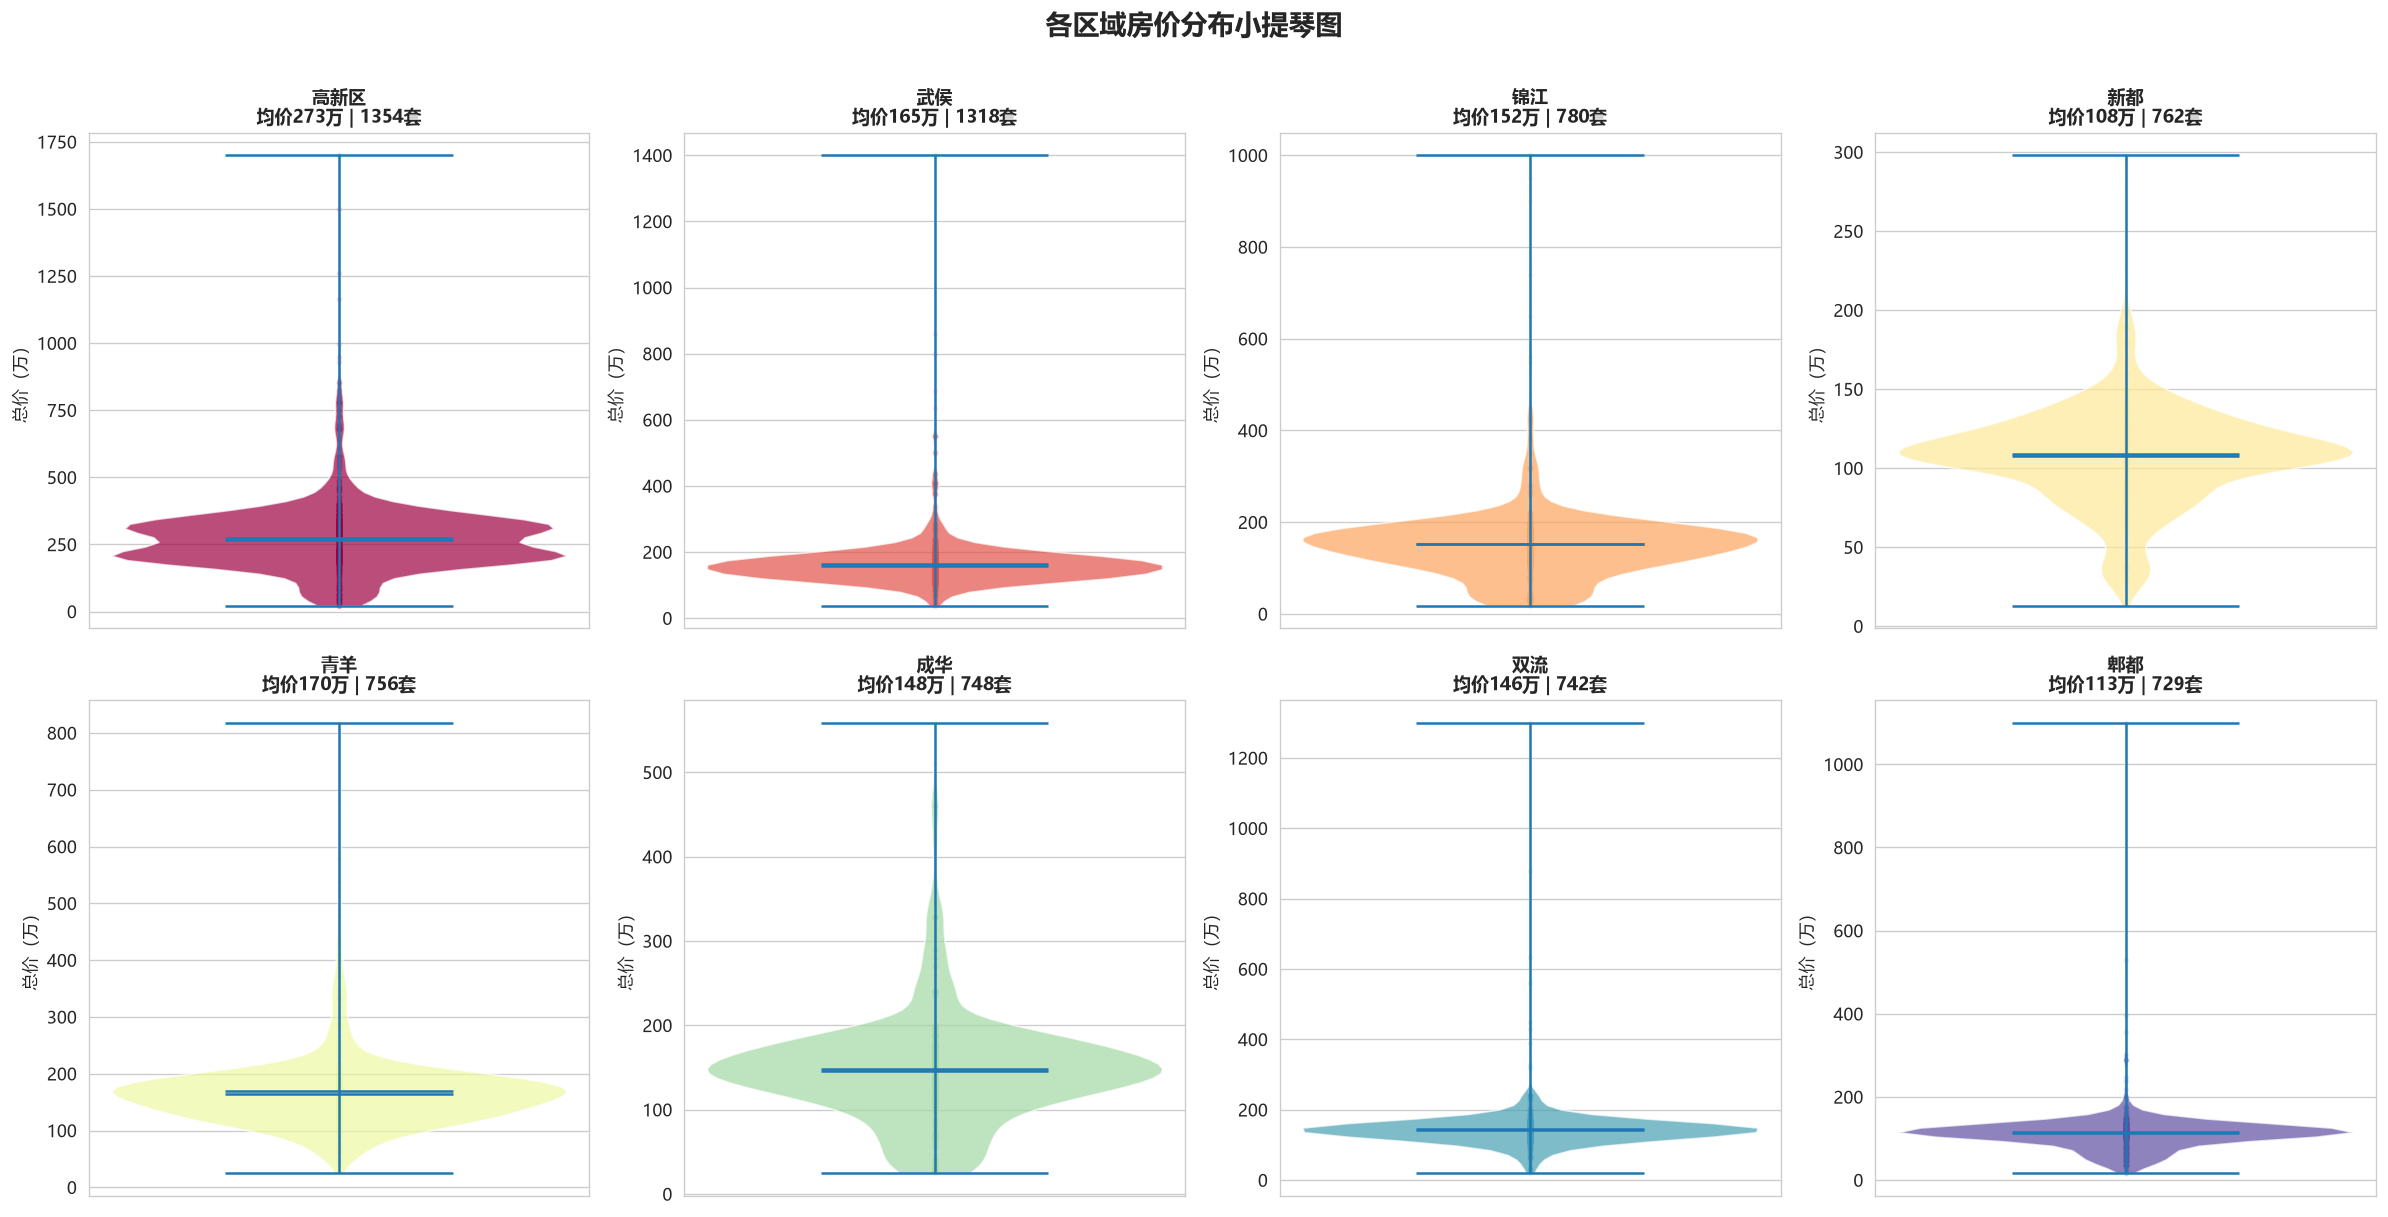

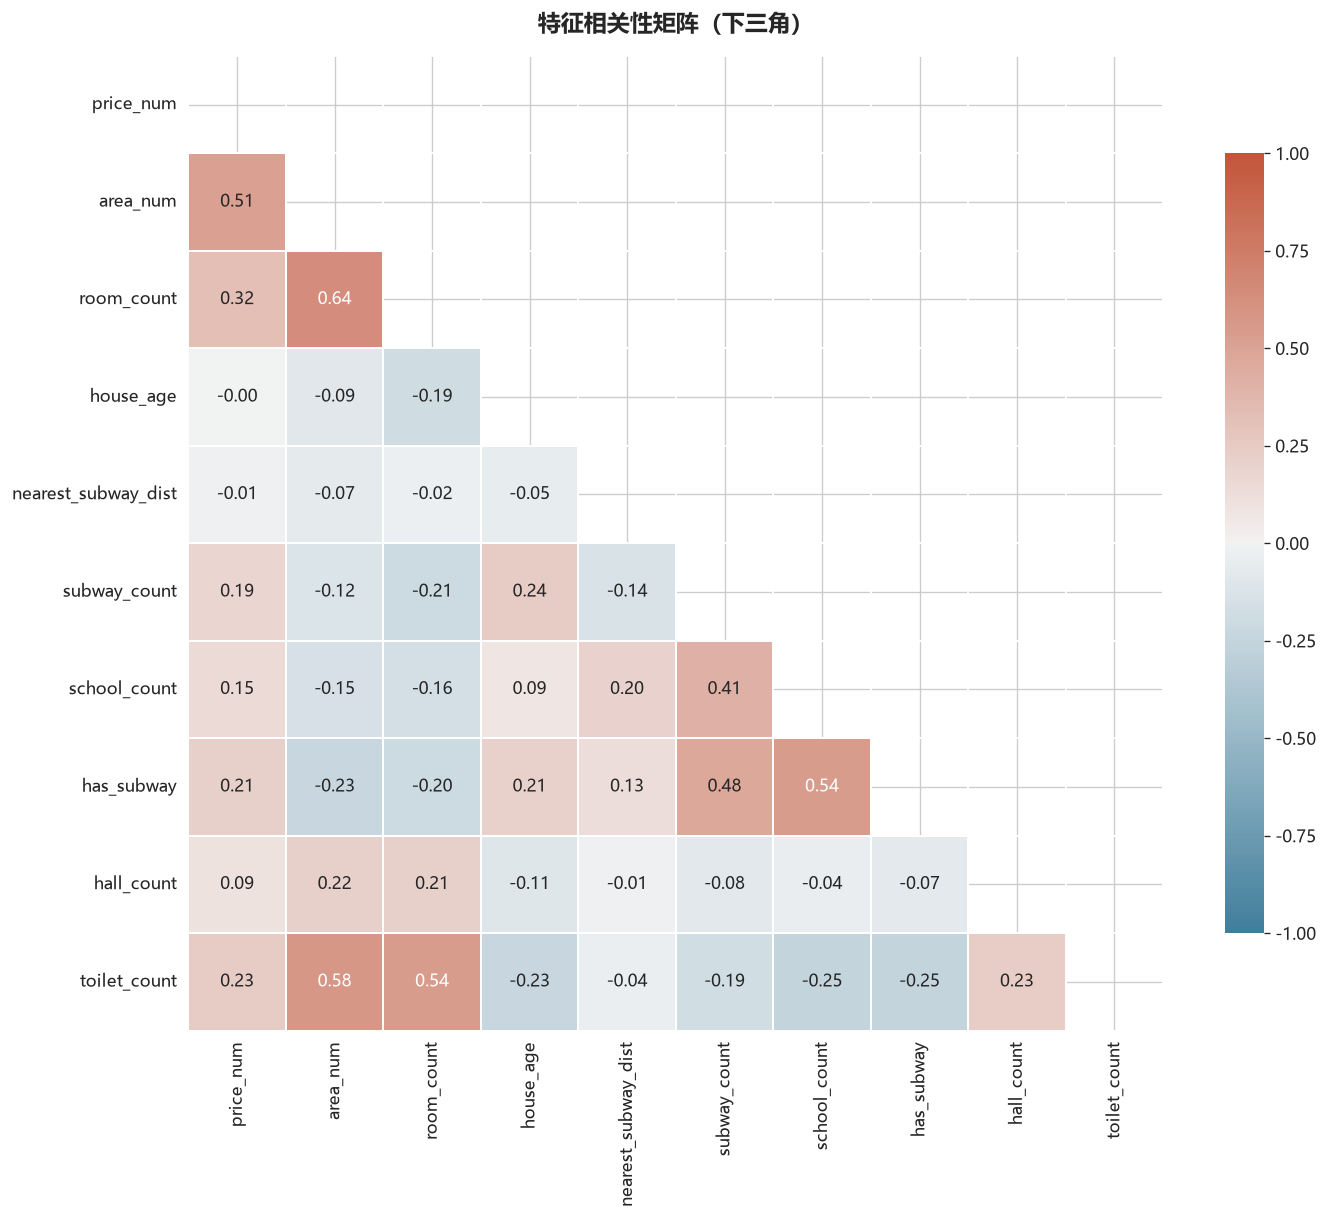

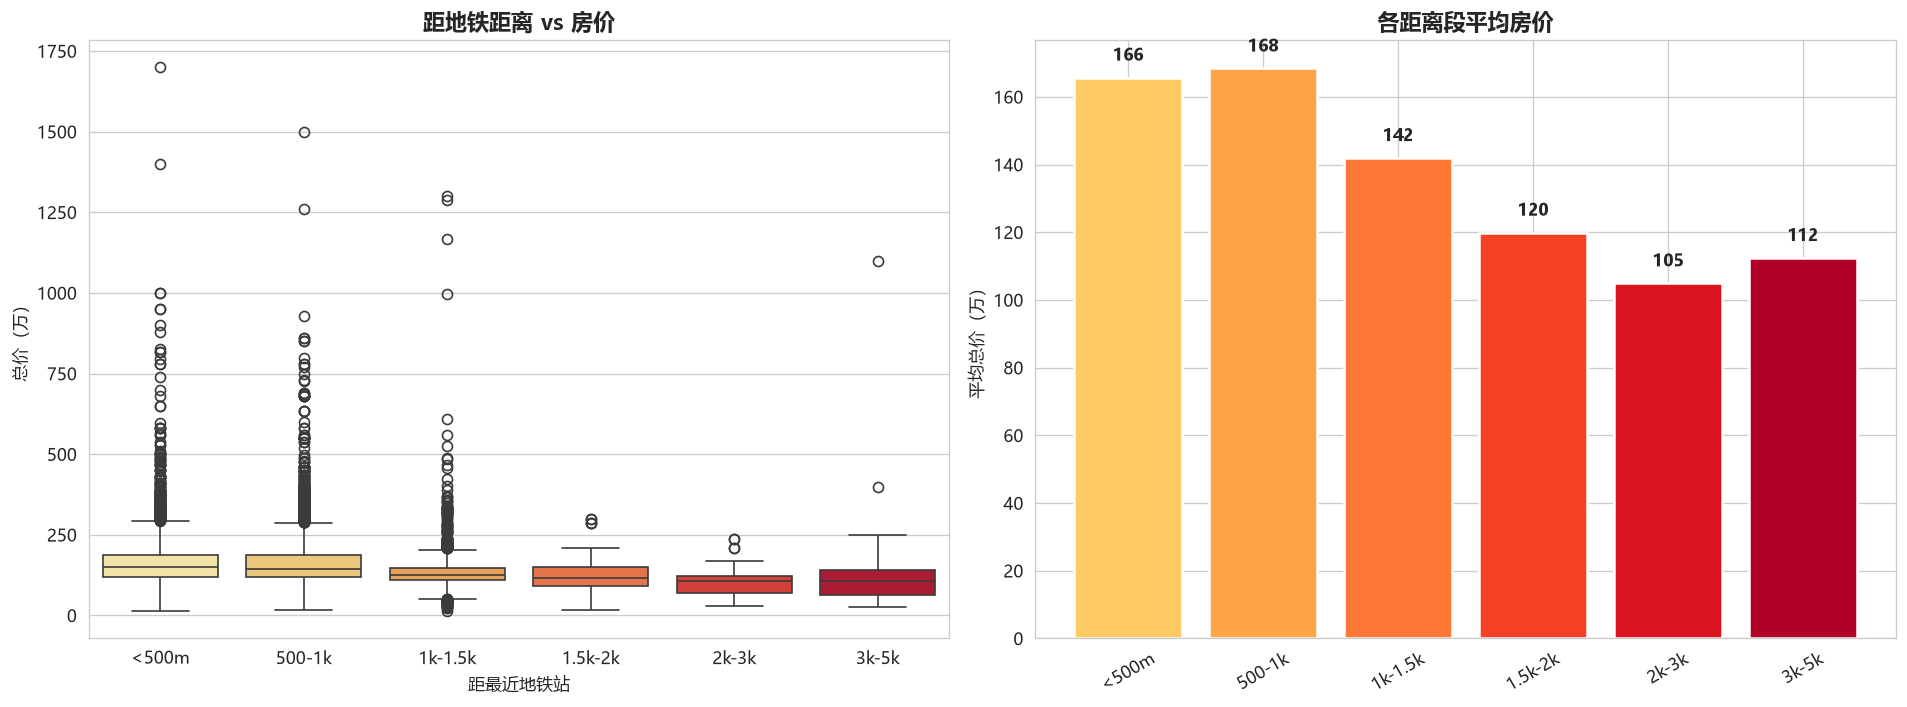

In [7]:
# 各区域房价小提琴图
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
top8 = df['district'].value_counts().head(8).index
colors = plt.cm.Spectral(np.linspace(0, 1, 8))

for i, d in enumerate(top8):
    data = df[df['district'] == d]['price_num']
    parts = axes[i].violinplot(data, positions=[0], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    axes[i].scatter([0]*len(data), data, alpha=0.1, s=6, color=colors[i])
    axes[i].set_title(f'{d}\n均价{data.mean():.0f}万 | {len(data)}套', 
                      fontsize=11, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].set_ylabel('总价（万）')

plt.suptitle('各区域房价分布小提琴图', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# 相关性热力图
corr_cols = ['price_num', 'area_num', 'room_count', 'house_age',
             'nearest_subway_dist', 'subway_count', 'school_count',
             'has_subway', 'has_school'] + [c for c in X_train_adv.columns if '_te' in c or '_' in c][:5]
corr_cols = list(dict.fromkeys(corr_cols))  # 去重
corr = df[[c for c in corr_cols if c in df.columns]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=1, annot=True, fmt='.2f',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('特征相关性矩阵（下三角）', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig2_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# 距地铁距离分箱分析
subway_df = df[df['nearest_subway_dist'] >= 0].copy()
subway_df['subway_bin'] = pd.cut(
    subway_df['nearest_subway_dist'],
    bins=[0, 500, 1000, 1500, 2000, 3000, 5000],
    labels=['<500m', '500-1k', '1k-1.5k', '1.5k-2k', '2k-3k', '3k-5k']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=subway_df, x='subway_bin', y='price_num', 
            palette='YlOrRd', ax=axes[0])
axes[0].set_title('距地铁距离 vs 房价', fontsize=13, fontweight='bold')
axes[0].set_xlabel('距最近地铁站')
axes[0].set_ylabel('总价（万）')

avg_by_bin = subway_df.groupby('subway_bin')['price_num'].mean()
bars = axes[1].bar(range(len(avg_by_bin)), avg_by_bin.values, 
                   color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(avg_by_bin))),
                   edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(avg_by_bin)))
axes[1].set_xticklabels(avg_by_bin.index, rotation=30)
axes[1].set_title('各距离段平均房价', fontsize=13, fontweight='bold')
axes[1].set_ylabel('平均总价（万）')
for i, v in enumerate(avg_by_bin.values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig3_subway.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
models = {
    'Ridge': Ridge(alpha=10.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42, max_iter=5000),
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=300, max_depth=15, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=400, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=400, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
}

results = []
trained_models = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("开始训练模型")

for name, model in models.items():
    t0 = time.time()
    is_linear = name in ['Ridge', 'Lasso', 'ElasticNet']
    X_tr = X_train_scaled if is_linear else X_train_tree
    X_te = X_test_scaled if is_linear else X_test_tree
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    # 交叉验证
    cv_scores = cross_val_score(model, X_tr, y_train, cv=kf, scoring='r2', n_jobs=-1)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    elapsed = time.time() - t0
    
    results.append({
        '模型': name,
        'RMSE(万)': round(rmse, 2),
        'MAE(万)': round(mae, 2),
        'R2': round(r2, 4),
        'CV_R2_mean': round(cv_scores.mean(), 4),
        'CV_R2_std': round(cv_scores.std(), 4),
        '耗时(s)': round(elapsed, 1)
    })
    trained_models[name] = model
    
    print(f"{name:18s} | R2={r2:.4f} | RMSE={rmse:.1f} | CV={cv_scores.mean():.4f} | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("模型排名（按测试集R2）：")
print(results_df.to_string(index=False))

开始训练模型
Ridge              | R2=0.6669 | RMSE=49.6 | CV=0.6326 | 3.0s
Lasso              | R2=0.6529 | RMSE=50.6 | CV=0.6310 | 3.1s
ElasticNet         | R2=0.6513 | RMSE=50.7 | CV=0.6303 | 1.8s
RandomForest       | R2=0.8691 | RMSE=31.1 | CV=0.8175 | 12.3s
ExtraTrees         | R2=0.8975 | RMSE=27.5 | CV=0.8162 | 4.5s
GradientBoosting   | R2=0.8932 | RMSE=28.1 | CV=0.8383 | 17.6s
XGBoost            | R2=0.9083 | RMSE=26.0 | CV=0.8409 | 2.6s


  File "d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\ANACONDA\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LightGBM           | R2=0.8573 | RMSE=32.4 | CV=0.7846 | 4.5s
模型排名（按测试集R2）：
              模型  RMSE(万)  MAE(万)     R2  CV_R2_mean  CV_R2_std  耗时(s)
         XGBoost    26.00   15.33 0.9083      0.8409     0.0223    2.6
      ExtraTrees    27.49   16.94 0.8975      0.8162     0.0273    4.5
GradientBoosting    28.06   17.07 0.8932      0.8383     0.0229   17.6
    RandomForest    31.07   17.52 0.8691      0.8175     0.0342   12.3
        LightGBM    32.44   19.95 0.8573      0.7846     0.0188    4.5
           Ridge    49.56   30.51 0.6669      0.6326     0.0190    3.0
           Lasso    50.59   31.18 0.6529      0.6310     0.0089    3.1
      ElasticNet    50.71   31.28 0.6513      0.6303     0.0126    1.8


In [9]:
# 粗调
MODEL_PATH = 'best_xgboost_model.pkl'

coarse_params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [6],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

grid_coarse = GridSearchCV(
    xgb_base, coarse_params,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1, verbose=0
)

t0 = time.time()
grid_coarse.fit(X_train_tree, y_train)
elapsed = time.time() - t0

print(f"完成 | 耗时: {elapsed:.1f}s")
print(f"最优: {grid_coarse.best_params_}")
print(f"CV_R2: {grid_coarse.best_score_:.4f}")

best_n_est = grid_coarse.best_params_['n_estimators']
best_lr = grid_coarse.best_params_['learning_rate']

完成 | 耗时: 3.8s
最优: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}
CV_R2: 0.8367


In [10]:
# 精调
fine_params = {
    'n_estimators': [best_n_est],
    'learning_rate': [best_lr],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

grid_fine = GridSearchCV(
    xgb_base, fine_params,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1, verbose=0
)

t0 = time.time()
grid_fine.fit(X_train_tree, y_train)
elapsed = time.time() - t0

print(f"完成，耗时: {elapsed:.1f}s")
print(f"最优参数:")
for k, v in grid_fine.best_params_.items():
    print(f"  {k}: {v}")
print(f"CV_R2: {grid_fine.best_score_:.4f}")

best_xgb = grid_fine.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_tree)

r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"\n调优后测试集:")
print(f"  R2 = {r2_tuned:.4f}")
print(f"  RMSE = {rmse_tuned:.2f}万")
print(f"  MAE = {mae_tuned:.2f}万")

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_xgb, f)
print(f"\n模型已保存: {MODEL_PATH}")

完成，耗时: 659.3s
最优参数:
  colsample_bytree: 0.7
  learning_rate: 0.1
  max_depth: 8
  n_estimators: 500
  reg_alpha: 0.1
  reg_lambda: 2
  subsample: 0.9
CV_R2: 0.8391

调优后测试集:
  R2 = 0.9094
  RMSE = 25.85万
  MAE = 14.07万

模型已保存: best_xgboost_model.pkl


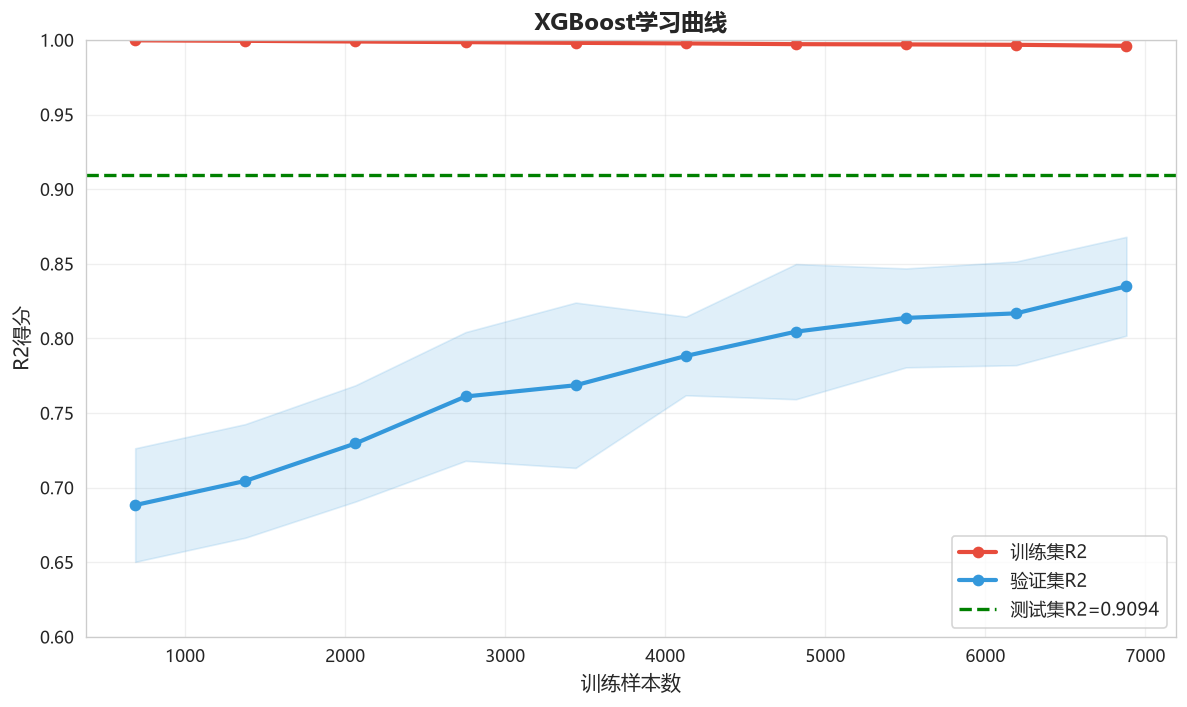

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb, X_train_tree, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', linewidth=2.5, label='训练集R2')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, val_mean, 'o-', color='#3498db', linewidth=2.5, label='验证集R2')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3498db')
ax.axhline(y=r2_tuned, color='green', linestyle='--', linewidth=2, label=f'测试集R2={r2_tuned:.4f}')
ax.set_xlabel('训练样本数', fontsize=12)
ax.set_ylabel('R2得分', fontsize=12)
ax.set_title('XGBoost学习曲线', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0.6, 1.0])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

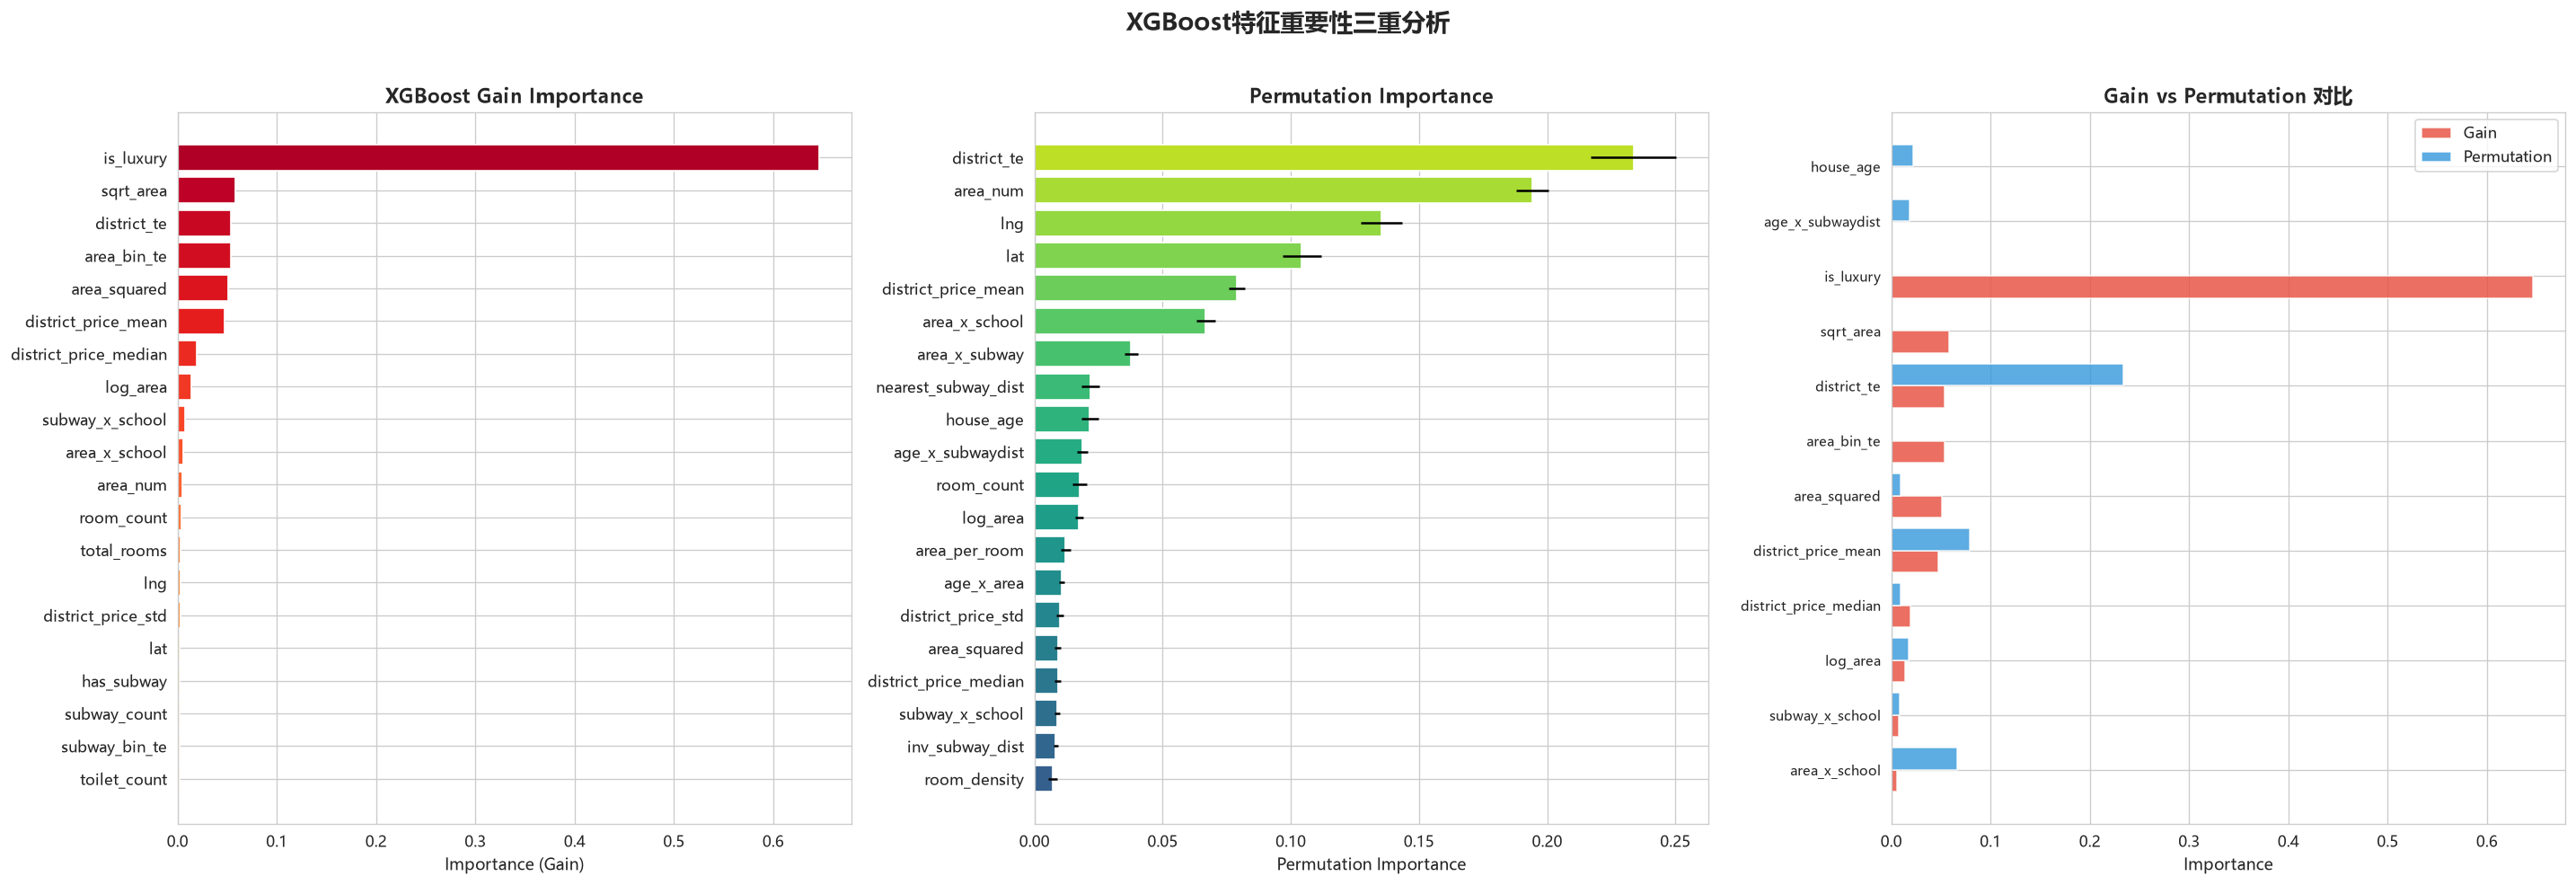

Top 10 特征:
   1. is_luxury                 (gain: 0.6465)
   2. sqrt_area                 (gain: 0.0583)
   3. district_te               (gain: 0.0533)
   4. area_bin_te               (gain: 0.0533)
   5. area_squared              (gain: 0.0507)
   6. district_price_mean       (gain: 0.0472)
   7. district_price_median     (gain: 0.0192)
   8. log_area                  (gain: 0.0142)
   9. subway_x_school           (gain: 0.0076)
  10. area_x_school             (gain: 0.0059)


In [12]:
with open('best_xgboost_model.pkl', 'rb') as f:
    best_xgb = pickle.load(f)

feature_names = list(X_train_filled.columns)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 内置重要性
imp_gain = pd.DataFrame({
    'feature': feature_names,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

colors1 = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(imp_gain)))
axes[0].barh(imp_gain['feature'], imp_gain['importance'], color=colors1, edgecolor='white')
axes[0].set_xlabel('Importance (Gain)', fontsize=11)
axes[0].set_title('XGBoost Gain Importance', fontsize=13, fontweight='bold')

# 排列重要性
from sklearn.inspection import permutation_importance
perm_imp = permutation_importance(best_xgb, X_test_tree, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_imp.importances_mean,
    'std': perm_imp.importances_std
}).sort_values('importance', ascending=True).tail(20)

colors2 = plt.cm.viridis(np.linspace(0.3, 0.9, len(perm_df)))
axes[1].barh(perm_df['feature'], perm_df['importance'], xerr=perm_df['std'], color=colors2, edgecolor='white')
axes[1].set_xlabel('Permutation Importance', fontsize=11)
axes[1].set_title('Permutation Importance', fontsize=13, fontweight='bold')

# Top10对比
top10_gain = imp_gain.tail(10)['feature'].tolist()
top10_perm = perm_df.tail(10)['feature'].tolist()

all_top = list(dict.fromkeys(top10_gain + top10_perm))[:12]
gain_vals = [imp_gain.set_index('feature').loc[f, 'importance'] if f in imp_gain['feature'].values else 0 for f in all_top]
perm_vals = [perm_df.set_index('feature').loc[f, 'importance'] if f in perm_df['feature'].values else 0 for f in all_top]

x_pos = np.arange(len(all_top))
axes[2].barh(x_pos - 0.2, gain_vals, 0.4, label='Gain', color='#e74c3c', alpha=0.8)
axes[2].barh(x_pos + 0.2, perm_vals, 0.4, label='Permutation', color='#3498db', alpha=0.8)
axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(all_top, fontsize=9)
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Gain vs Permutation 对比', fontsize=13, fontweight='bold')
axes[2].legend()

plt.suptitle('XGBoost特征重要性三重分析', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 特征:")
for i, f in enumerate(reversed(all_top[:10]), 1):
    g = imp_gain.set_index('feature').loc[f, 'importance'] if f in imp_gain['feature'].values else 0
    print(f"  {i:2d}. {f:25s} (gain: {g:.4f})")

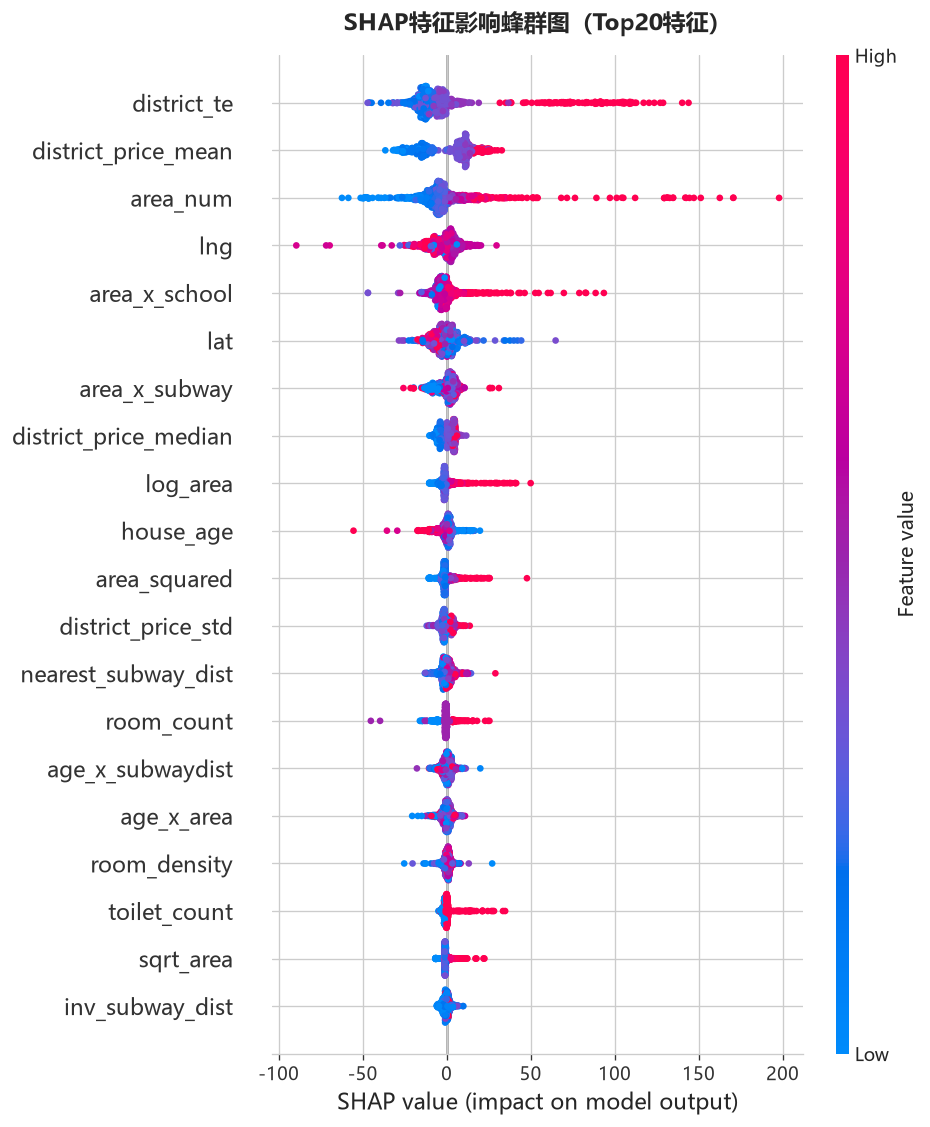

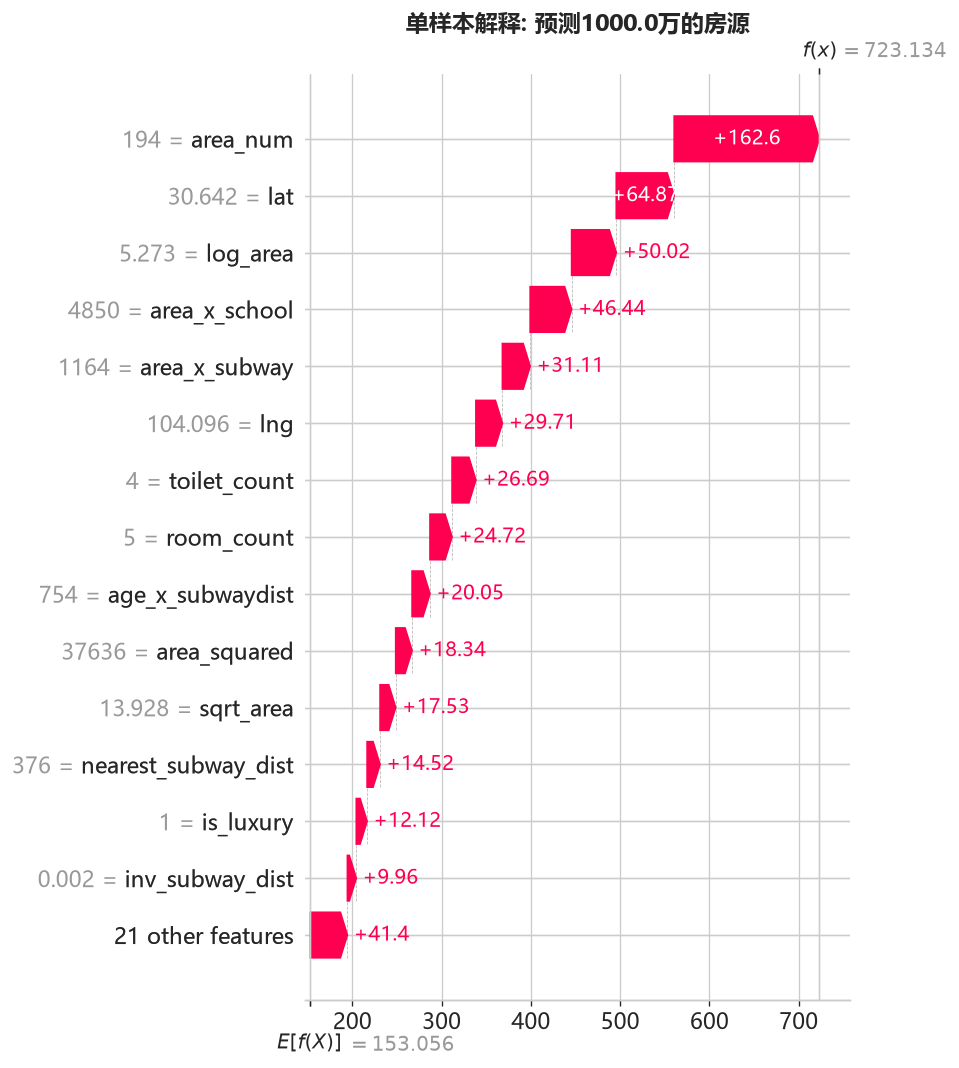

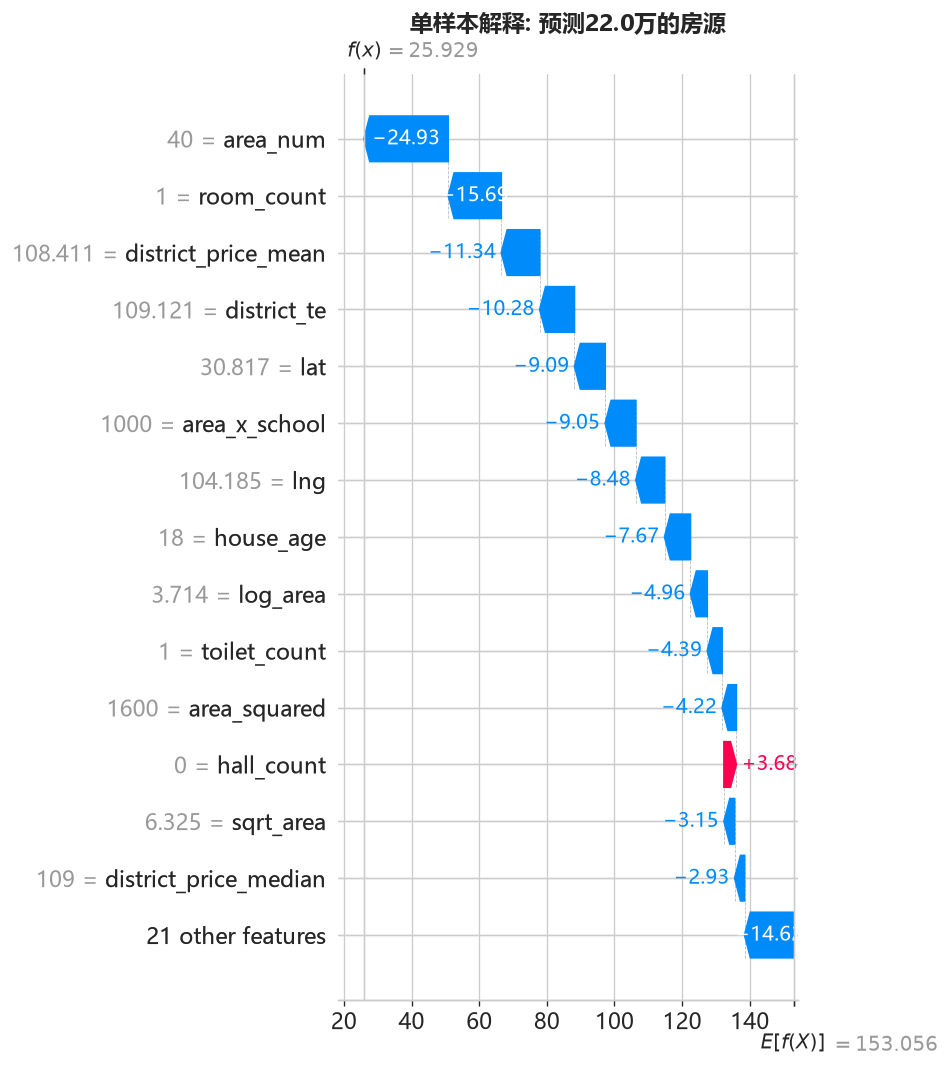

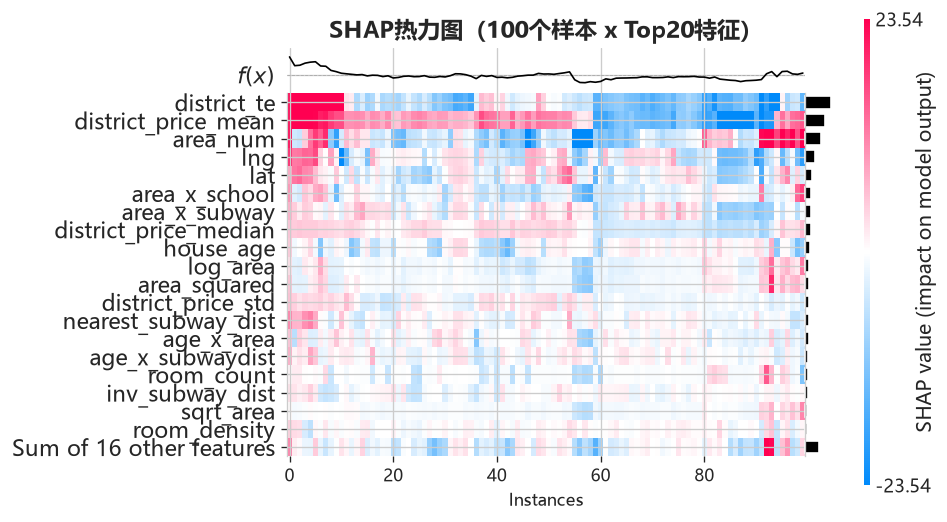


SHAP解读:
  红色=推高房价 | 蓝色=拉低房价 | 箭头长度=影响程度
  基础期望房价: 153.1万


In [13]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_tree[:1000])
X_shap = X_test_filled.iloc[:1000]

# 11.1 Summary Plot（蜂群图）
fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False, max_display=20)
plt.title('SHAP特征影响蜂群图（Top20特征）', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 11.2 Waterfall: 单样本解释（最高房价）
idx_max = np.argmax(y_test[:1000])
fig, ax = plt.subplots(figsize=(14, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_max],
    base_values=explainer.expected_value,
    data=X_shap.iloc[idx_max],
    feature_names=feature_names
), max_display=15, show=False)
plt.title(f'单样本解释: 预测{y_test[idx_max]:.1f}万的房源', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_waterfall_max.png', dpi=150, bbox_inches='tight')
plt.show()

# 11.3 Waterfall: 单样本解释（最低房价）
idx_min = np.argmin(y_test[:1000])
fig, ax = plt.subplots(figsize=(14, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_min],
    base_values=explainer.expected_value,
    data=X_shap.iloc[idx_min],
    feature_names=feature_names
), max_display=15, show=False)
plt.title(f'单样本解释: 预测{y_test[idx_min]:.1f}万的房源', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_waterfall_min.png', dpi=150, bbox_inches='tight')
plt.show()

# 11.4 热力图（100样本 x Top20特征）
fig, ax = plt.subplots(figsize=(16, 10))
shap.plots.heatmap(shap.Explanation(
    values=shap_values[:100],
    base_values=explainer.expected_value,
    data=X_shap.iloc[:100],
    feature_names=feature_names
), show=False, max_display=20)
plt.title('SHAP热力图（100个样本 x Top20特征）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSHAP解读:")
print("  红色=推高房价 | 蓝色=拉低房价 | 箭头长度=影响程度")
print(f"  基础期望房价: {explainer.expected_value:.1f}万")



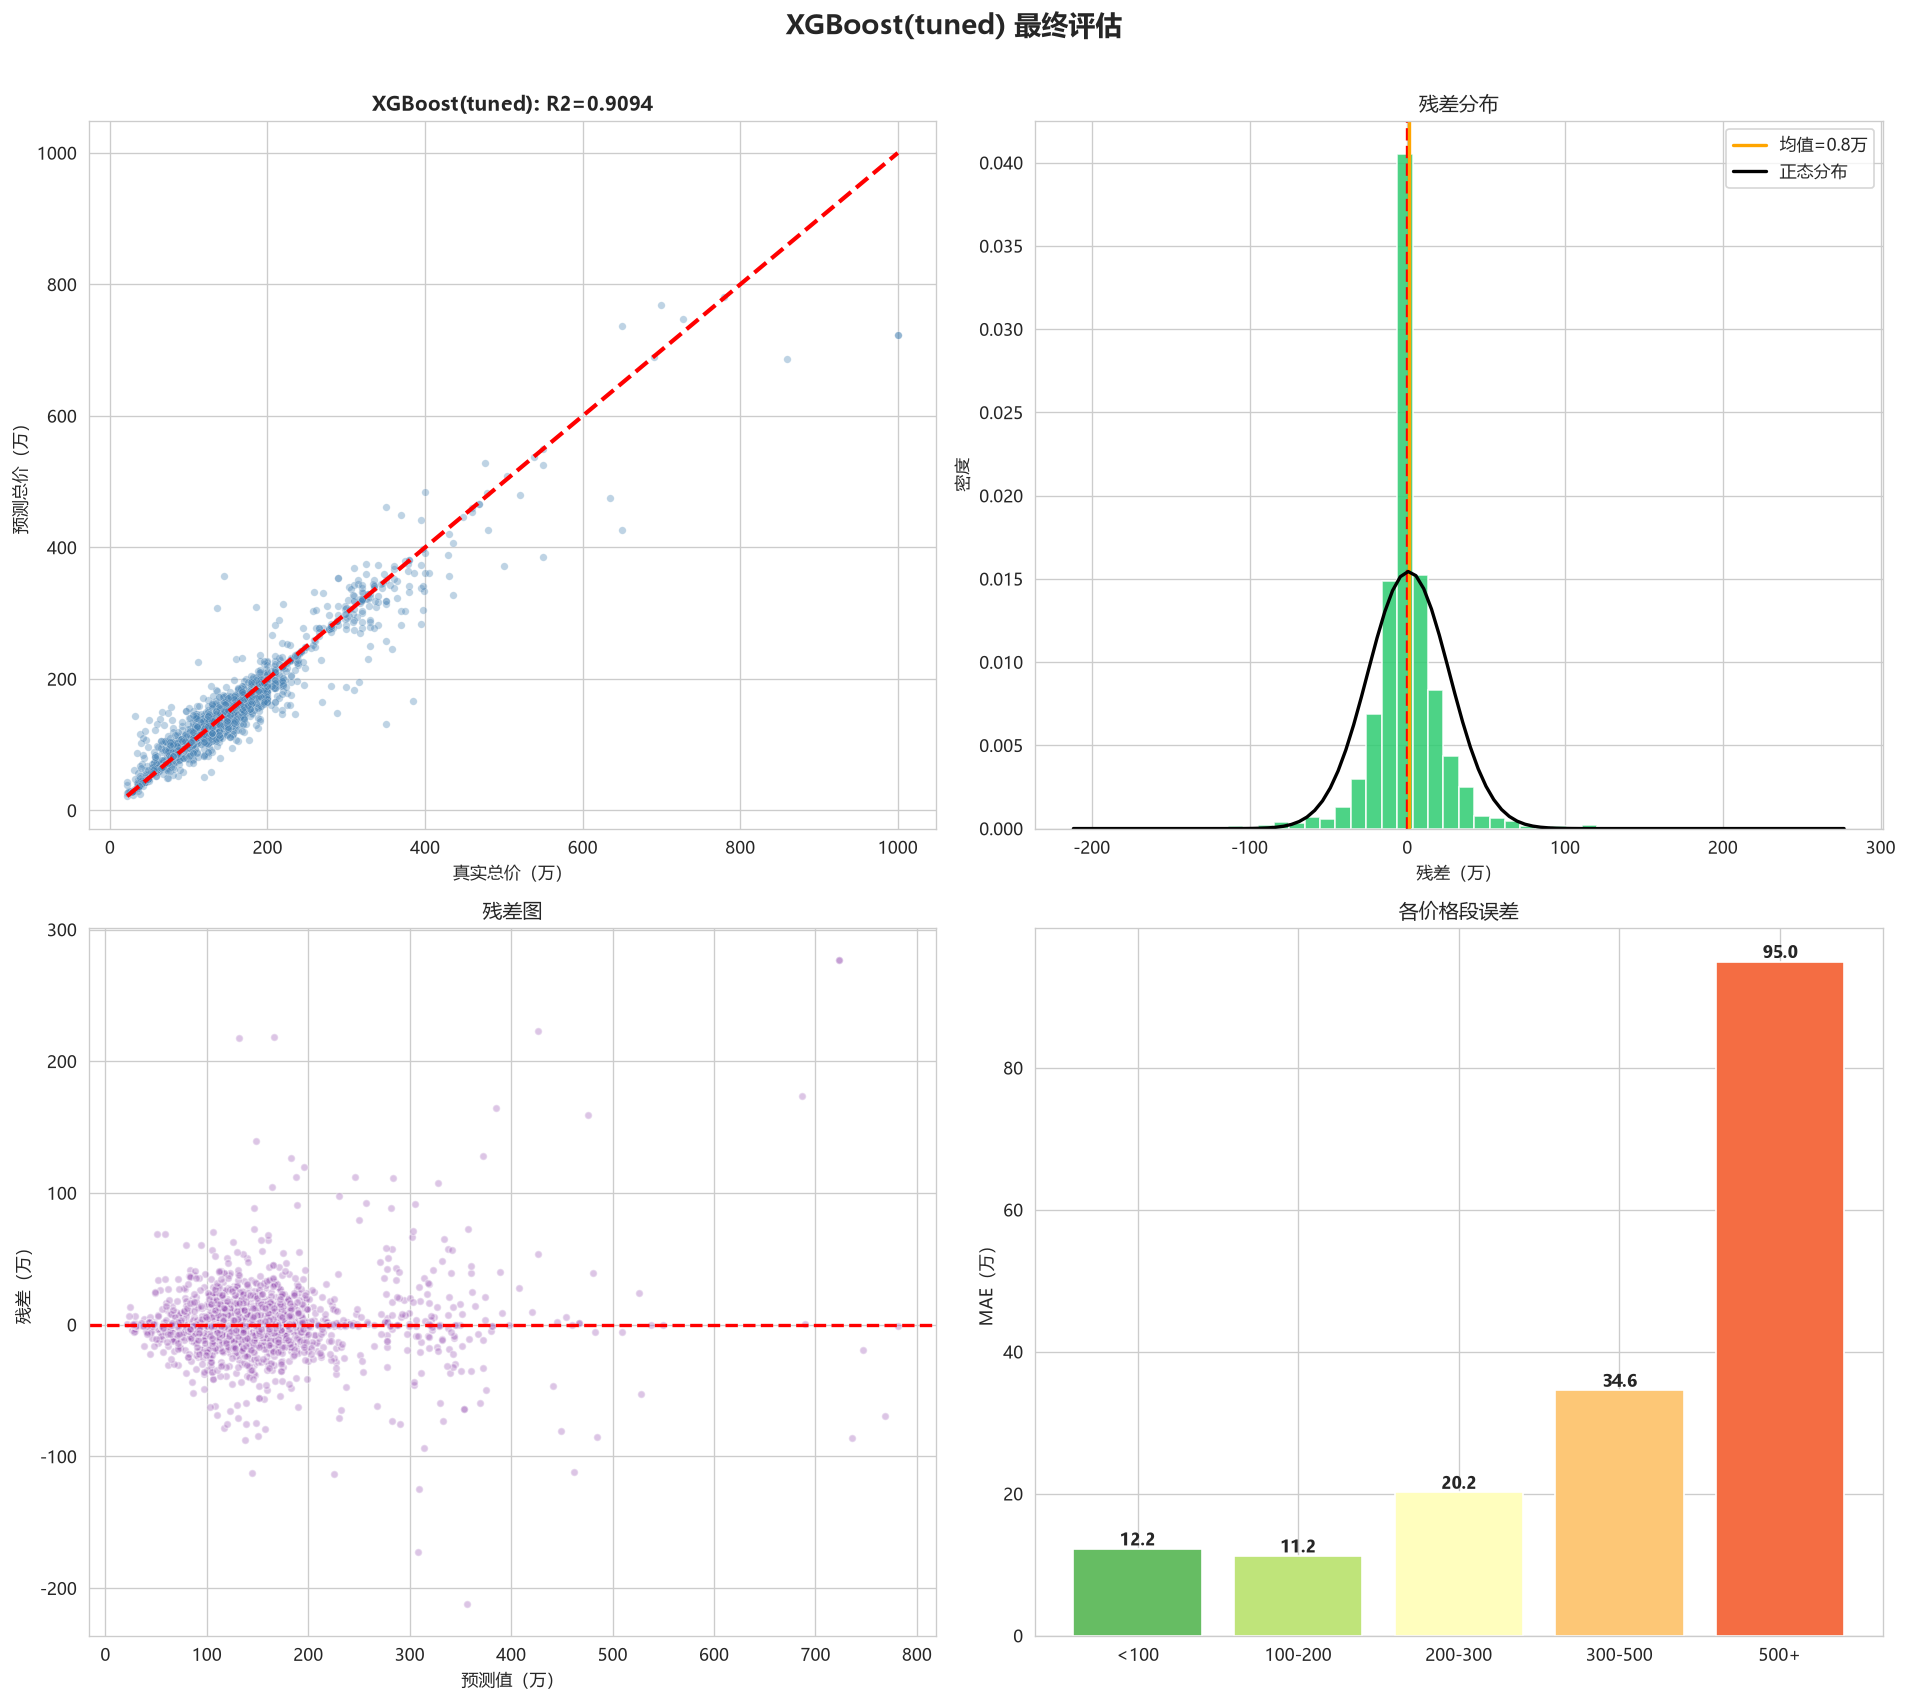

In [21]:
y_pred_final = best_xgb.predict(X_test_tree)
res = y_test - y_pred_final

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

axes[0,0].scatter(y_test, y_pred_final, alpha=0.35, s=20, c='steelblue', edgecolors='white', linewidth=0.3)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5)
axes[0,0].set_xlabel('真实总价（万）')
axes[0,0].set_ylabel('预测总价（万）')
axes[0,0].set_title(f'XGBoost(tuned): R2={r2_tuned:.4f}', fontsize=12, fontweight='bold')

axes[0,1].hist(res, bins=50, color='#2ecc71', edgecolor='white', density=True, alpha=0.85)
axes[0,1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0,1].axvline(x=res.mean(), color='orange', lw=2, label=f'均值={res.mean():.1f}万')
from scipy import stats
x_norm = np.linspace(res.min(), res.max(), 100)
axes[0,1].plot(x_norm, stats.norm.pdf(x_norm, res.mean(), res.std()), 'k-', lw=2, label='正态分布')
axes[0,1].set_xlabel('残差（万）')
axes[0,1].set_ylabel('密度')
axes[0,1].set_title('残差分布')
axes[0,1].legend()

axes[1,0].scatter(y_pred_final, res, alpha=0.35, s=20, c='#9b59b6', edgecolors='white')
axes[1,0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1,0].set_xlabel('预测值（万）')
axes[1,0].set_ylabel('残差（万）')
axes[1,0].set_title('残差图')

price_bins = pd.cut(y_test, bins=[0,100,200,300,500,2000], labels=['<100','100-200','200-300','300-500','500+'])
bin_errors = pd.DataFrame({'段': price_bins, '误差': np.abs(res)}).groupby('段')['误差'].mean()
axes[1,1].bar(range(len(bin_errors)), bin_errors.values, color=plt.cm.RdYlGn_r(np.linspace(0.2,0.8,len(bin_errors))), edgecolor='white')
axes[1,1].set_xticks(range(len(bin_errors)))
axes[1,1].set_xticklabels(bin_errors.index)
axes[1,1].set_ylabel('MAE（万）')
axes[1,1].set_title('各价格段误差')
for i, v in enumerate(bin_errors.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('XGBoost(tuned) 最终评估', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle
from pathlib import Path

OUTPUT_DIR = Path(r"D:\2024111712-章泽俊-数据科学期末大作业\house-website\ml")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_DIR / "xgboost_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
print("[OK] xgboost_model.pkl")

with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("[OK] scaler.pkl")

with open(OUTPUT_DIR / "enc_map.pkl", "wb") as f:
    pickle.dump(enc_map, f)
print("[OK] enc_map.pkl")

with open(OUTPUT_DIR / "feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)
print("[OK] feature_names.pkl")

print(f"\n 所有文件已保存！目录: {OUTPUT_DIR}")

[OK] xgboost_model.pkl
[OK] scaler.pkl
[OK] enc_map.pkl
[OK] feature_names.pkl

 所有文件已保存！目录: D:\2024111712-章泽俊-数据科学期末大作业\house-website\ml
